In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
from sklearn.neighbors import KernelDensity

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [3]:
RADIUS = 0.5
def sample_data(n, rng=None):
    centers = 2 * torch.rand(n, 2, generator=rng) - 1

    r = torch.sqrt(torch.rand(n, 1, generator=rng)) * RADIUS
    theta = torch.rand(n, 1, generator=rng) * 2 * torch.pi
    offsets = torch.hstack([r * torch.cos(theta), r * torch.sin(theta)])

    points = centers + offsets
    
    return points.to(device), centers.to(device)

In [4]:
def energy(x, y, sigma=0.5):
    d = torch.maximum(torch.tensor(0), torch.norm(x - y, dim=-1) - RADIUS)

    # return d
    return 1.0 - torch.exp(-d**2/(sigma**2))

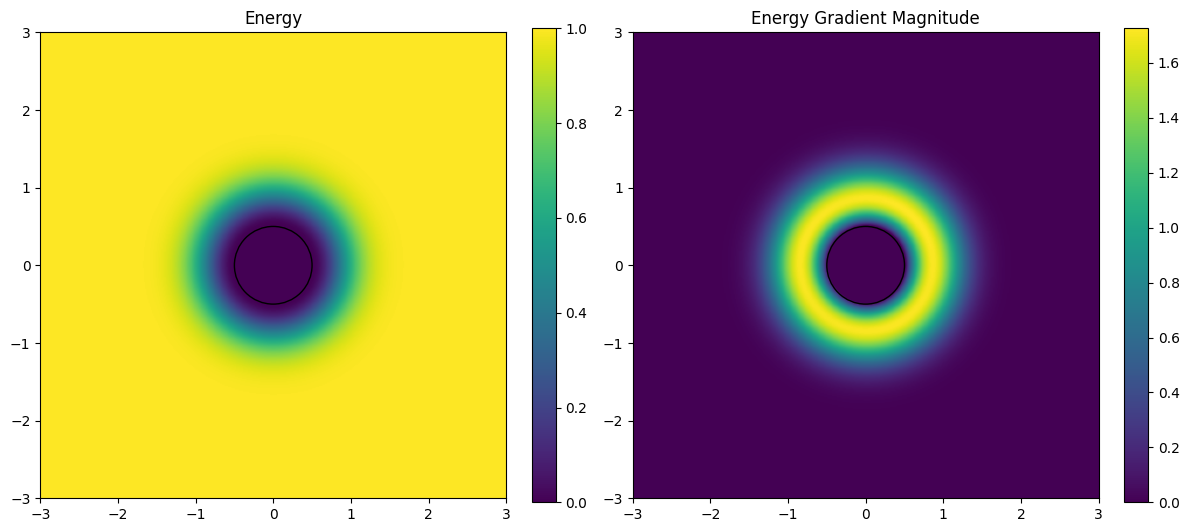

In [5]:
extent = 3
x = torch.linspace(-extent, extent, 400)
y = torch.linspace(-extent, extent, 400)
X, Y = torch.meshgrid(x, y, indexing="xy")
Z = energy(torch.stack([X.flatten(), Y.flatten()], dim=1), torch.zeros(1, 2), sigma=0.5).reshape(X.shape).cpu()

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

for ax in axs:
    ax.add_patch(Circle((0, 0), radius=RADIUS, facecolor="none", edgecolor="black"))
    ax.grid(False)

grad = torch.sqrt(Z.diff(dim=0)[:, :-1]**2 + Z.diff(dim=1)[:-1, :]**2) / x.diff()[0]
im_0 = axs[0].imshow(Z, extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')
im_1 = axs[1].imshow(grad, extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')

axs[0].set_title("Energy")
axs[1].set_title("Energy Gradient Magnitude")

_ = fig.colorbar(im_0, ax=axs[0], fraction=0.046)
_ = fig.colorbar(im_1, ax=axs[1], fraction=0.046)

In [6]:
T = 100
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

lambda_t = torch.linspace(4.0, 0.0, T).to(device)

Text(0.5, 1.0, '$\\bar{\\alpha}_t$')

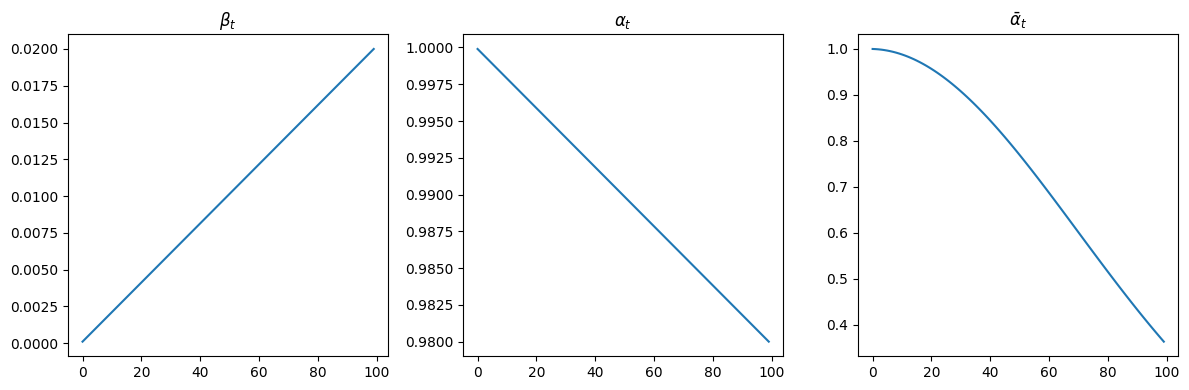

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
axs[0].plot(betas.cpu())
axs[1].plot(alphas.cpu())
axs[2].plot(alphas_cumprod.cpu())

axs[0].set_title(r"$\beta_t$")
axs[1].set_title(r"$\alpha_t$")
axs[2].set_title(r"$\bar{\alpha}_t$")

In [8]:
def q_sample(x0, t, noise):
    a_bar = alphas_cumprod[t].view(-1, 1)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

In [9]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, y, t):
        t = t.float() / T
        t = t.unsqueeze(1)
        inp = torch.cat([x, y, t], dim=1)
        return self.net(inp)

In [10]:
def train(mode="baseline", epochs=2000, batch_size=512):
    torch.manual_seed(0)
    model = MLP().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)

    for step in range(epochs):
        x0, y = sample_data(batch_size)
        t = torch.randint(0, T, (x0.size(0),), device=device)

        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)

        xt.requires_grad_(True)

        pred = model(xt, y, t)

        if mode == "eg_training":
            E = energy(xt, y)
            grad_E = torch.autograd.grad(E.sum(), xt)[0].detach()
            
            sigma_t = torch.sqrt(1 - alphas_cumprod[t]).unsqueeze(1)
            target = noise + lambda_t[t].reshape(-1, 1) * sigma_t * grad_E

        else:
            target = noise

        loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 200 == 0:
            print(f"{mode} step {step} loss {loss.item():.4f}")

    return model

In [11]:
def sample(model, y, mode="baseline", rng=None):
    if rng is None:
        rng = torch.Generator()
        rng.manual_seed(0)

    y = y.reshape(-1, 2).to(device)
    n, _ = y.shape
    x = torch.randn(n, 2, generator=rng).to(device)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        if mode == "sampling_guidance":
            x = x.clone().detach().requires_grad_(True)

        pred = model(x, y, t_batch)

        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]

        score = -pred / torch.sqrt(1 - alpha_bar)

        if mode == "sampling_guidance":
            E = energy(x, y)
            grad_E = torch.autograd.grad(E.sum(), x)[0].detach()

            score = score - lambda_t[t] * grad_E

        noise = torch.randn(x.shape, generator=rng).to(device) if t > 0 else 0

        x = 1 / torch.sqrt(alpha) * (x + (1 - alpha) * score) + torch.sqrt(betas[t]) * noise
        x = x.detach()

    return x

In [12]:
model_eg = train("eg_training")
model_base = train("baseline")

eg_training step 0 loss 1.6392
eg_training step 200 loss 0.4362
eg_training step 400 loss 0.3830
eg_training step 600 loss 0.3028
eg_training step 800 loss 0.3178
eg_training step 1000 loss 0.3240
eg_training step 1200 loss 0.2626
eg_training step 1400 loss 0.3180
eg_training step 1600 loss 0.2843
eg_training step 1800 loss 0.3124
baseline step 0 loss 1.0215
baseline step 200 loss 0.3215
baseline step 400 loss 0.3533
baseline step 600 loss 0.3005
baseline step 800 loss 0.3124
baseline step 1000 loss 0.3140
baseline step 1200 loss 0.2644
baseline step 1400 loss 0.3162
baseline step 1600 loss 0.2858
baseline step 1800 loss 0.3166


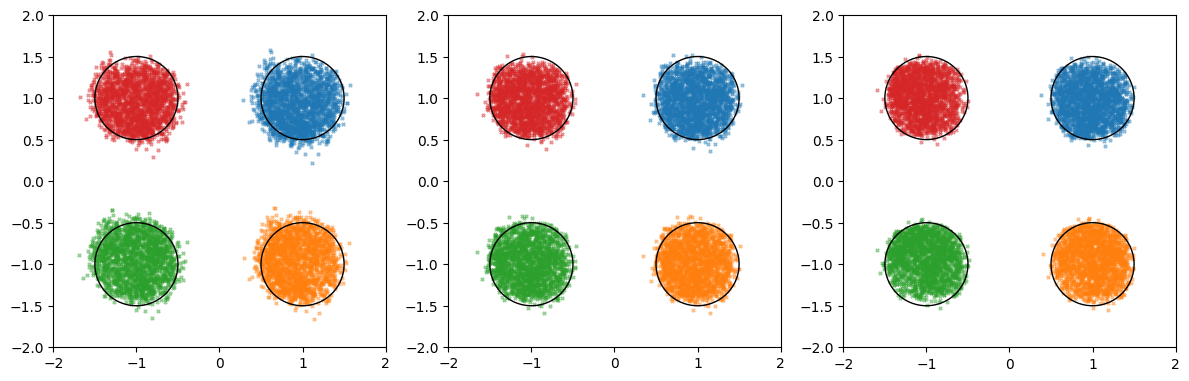

In [13]:
ys = torch.Tensor([
    [+1.0, +1.0],
    [+1.0, -1.0],
    [-1.0, -1.0],
    [-1.0, +1.0]
]).reshape(-1, 1, 2)

fig, axs = plt.subplots(1, 3, figsize=(12, 6), tight_layout=True)

kwargs = [
    {"model": model_base, "mode": "baseline"},
    {"model": model_base, "mode": "sampling_guidance"},
    {"model": model_eg, "mode": "baseline"},
]

for ax, kwarg in zip(axs, kwargs):
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect("equal")

    for y in ys:
        samples = sample(**kwarg, y=y.repeat(2000, 1)).cpu()
        ax.scatter(samples[:, 0], samples[:, 1], marker="x", s=5, alpha=0.5)
        ax.add_patch(Circle(y[0], radius=RADIUS, facecolor="none", edgecolor="black"))


In [14]:
def fraction_outside(x0, y):
    y = y.reshape(-1, 2)
    d = torch.norm(x0 - y, dim=1)

    return torch.mean((d > RADIUS).to(torch.float32))

In [15]:
n_samples = 100_000
y = 2 * torch.rand(n_samples, 2).to(device) - 1

samples_base = sample(model_base, y, mode="baseline")
samples_sampling_guided = sample(model_base, y, mode="sampling_guidance")
samples_training_guided = sample(model_eg, y, mode="baseline")

In [16]:
print(f"Fraction Outside Baseline         : {fraction_outside(samples_base, y):.4f}")
print(f"Fraction Outside Sampling Guidance: {fraction_outside(samples_sampling_guided, y):.4f}")
print(f"Fraction Outside Training Guidance: {fraction_outside(samples_training_guided, y):.4f}")

Fraction Outside Baseline         : 0.0696
Fraction Outside Sampling Guidance: 0.0343
Fraction Outside Training Guidance: 0.0212


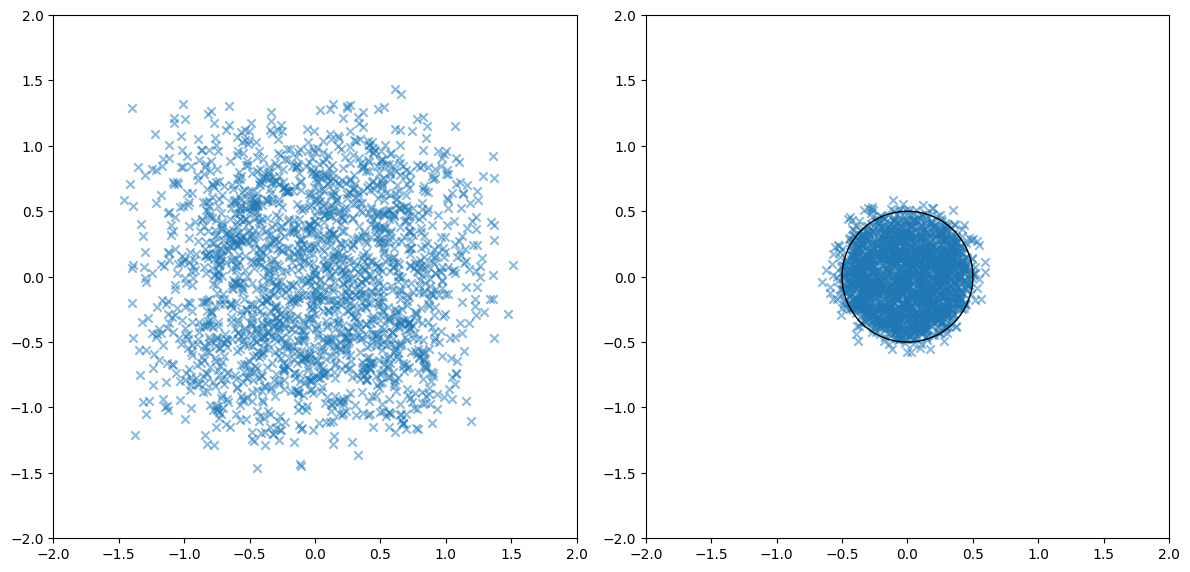

In [17]:
samples = samples_base.cpu()
y = y.cpu()

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

plot_samples = samples[:2000]
plot_samples_centered = samples[:2000] - y.cpu()[:2000]

axs[0].scatter(plot_samples[:, 0], plot_samples[:, 1], marker="x", alpha=0.5)
axs[1].scatter(plot_samples_centered[:, 0], plot_samples_centered[:, 1], marker="x", alpha=0.5)

_ = axs[1].add_patch(Circle((0, 0), radius=RADIUS, facecolor="none", edgecolor="black"))

In [18]:
kernel="tophat"
bandwidth="scott"
kde_base = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples_base.cpu() - y)
kde_sampling_guided = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples_sampling_guided.cpu() - y)
kde_training_guided = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples_training_guided.cpu() - y)

In [19]:
def plot_kde(ax, kde, extent, title):
    n = 200
    Z = np.dstack(
        np.meshgrid(
            np.linspace(-extent, extent, n), 
            np.linspace(-extent, extent, n)
        )
    ).reshape(-1, 2)

    p = kde.score_samples(Z).reshape(n, n)

    img = ax.imshow(p, extent=(-extent, extent, -extent, extent), origin="lower")
    ax.add_patch(Circle((0, 0), radius=RADIUS, edgecolor='black', facecolor='none', lw=1))
    ax.set_aspect("equal")
    ax.set_title(title)

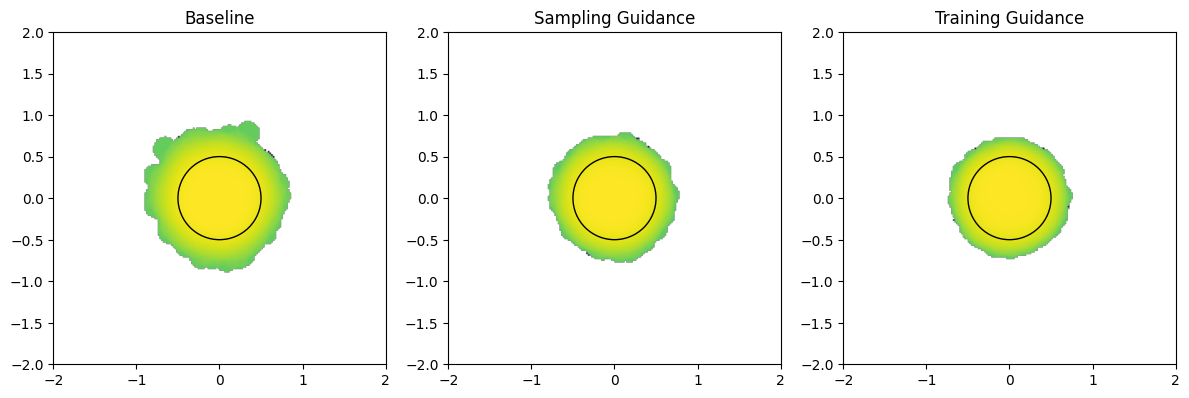

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
plot_kde(axs[0], kde_base, 2, title="Baseline")
plot_kde(axs[1], kde_sampling_guided, 2, title="Sampling Guidance")
plot_kde(axs[2], kde_training_guided, 2, title="Training Guidance")

In [21]:
def estimate_KL(kde):
    n = 100
    dx = 1/n
    p = 1 / (torch.pi * RADIUS**2)

    Z = np.dstack(
        np.meshgrid(
            np.linspace(-0.5, 0.5, n), 
            np.linspace(-0.5, 0.5, n)
        )
    ).reshape(-1, 2)

    r_mask = np.linalg.norm(Z, axis=1) < RADIUS
    Z = Z[r_mask]

    log_q = kde.score_samples(Z)

    return p * (np.log(p) - log_q).sum() * dx * dx

In [22]:
print(f"KL (Baseline)       : {estimate_KL(kde_base):.4f}")
print(f"KL (Sampling Guided): {estimate_KL(kde_sampling_guided):.4f}")
print(f"KL (Training Guided): {estimate_KL(kde_training_guided):.4f}")

KL (Baseline)       : 0.1696
KL (Sampling Guided): 0.1602
KL (Training Guided): 0.1555


# Guo et al. Energy Guidance

In [23]:
def train_guo(score_model, K=40, kappa=0.1, epochs=2000, batch_size=32):
    torch.manual_seed(0)
    rng = torch.Generator()
    rng.manual_seed(0)

    score_model.eval()
    h = MLP().to(device)
    opt = optim.Adam(h.parameters(), lr=1e-3)

    loss_agg = 0.0
    for step in range(1, epochs + 1):
        x0, y = sample_data(batch_size)
        t = torch.randint(0, T, (x0.size(0),), device=device)
        
        alpha_bar = alphas_cumprod[t, None, None]

        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)

        y_K = torch.repeat_interleave(y, K, dim=0)
        with torch.no_grad():
            x0_K = sample(score_model, y_K, mode="baseline", rng=rng)
        x0_K = x0_K.reshape(batch_size, K, 2)

        var = (1 - alpha_bar).view(-1, 1)
        diff = xt[:, None, :] - torch.sqrt(alpha_bar) * x0_K
        log_q = - (diff ** 2).sum(dim=-1) / (2 * var)

        with torch.no_grad():
            score = score_model(xt, y, t)
        score_i = -diff / (1 - alpha_bar)

        zeta = score[:, None, :] - score_i

        E0 = energy(x0_K, y[:, None, :])
        
        log_w = log_q - kappa * E0
        w_norm = torch.softmax(log_w, dim=1)

        Y = (w_norm[:, :, None] * zeta).sum(dim=1)
        
        pred = h(xt, y, t)
        loss = ((pred - Y) ** 2).sum(dim=-1).mean()
        loss_agg += loss.item()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 200 == 0:
            print(f"Step {step} loss {loss_agg/200:.4f}")
            loss_agg = 0.0
            

    return h

In [24]:
h = train_guo(model_base)

Step 200 loss 6490.8751
Step 400 loss 9507.0092
Step 600 loss 8202.8781
Step 800 loss 7067.4162
Step 1000 loss 7949.8936
Step 1200 loss 8991.7905
Step 1400 loss 7250.8207
Step 1600 loss 9539.9195
Step 1800 loss 6143.2931
Step 2000 loss 6723.6205


In [25]:
def sample_guo(score_model, energy_model, y, kappa=0.1, rng=None):
    score_model.eval()
    energy_model.eval()
    
    if rng is None:
        rng = torch.Generator()
        rng.manual_seed(0)

    y = y.reshape(-1, 2).to(device)
    n, _ = y.shape
    x = torch.randn(n, 2, generator=rng).to(device)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        pred = score_model(x, y, t_batch)

        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]

        score = -pred / torch.sqrt(1 - alpha_bar)
        score = score - kappa * energy_model(x, y, t_batch)

        noise = torch.randn(x.shape, generator=rng).to(device) if t > 0 else 0

        x = 1 / torch.sqrt(alpha) * (x + (1 - alpha) * score) + torch.sqrt(betas[t]) * noise
        x = x.detach()

    return x

In [26]:
samples_guo = sample_guo(model_base, h, y)

In [27]:
print(f"Fraction Outside Guo: {fraction_outside(samples_guo.cpu(), y):.4f}")

Fraction Outside Guo: 0.0407


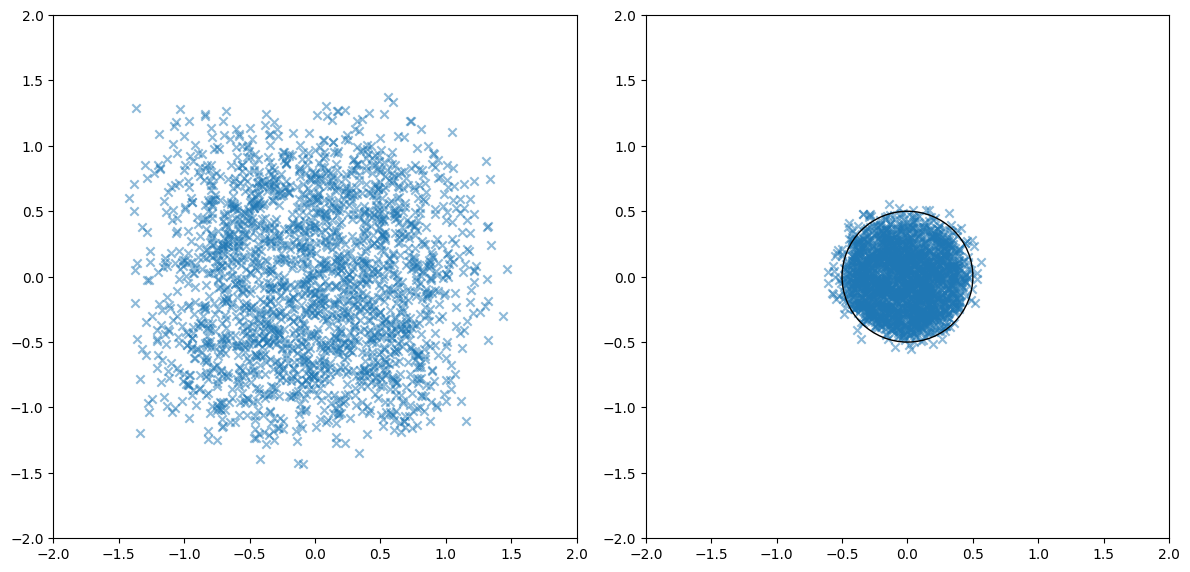

In [28]:
samples = samples_guo.cpu()
y = y.cpu()

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

plot_samples = samples[:2000]
plot_samples_centered = samples[:2000] - y.cpu()[:2000]

axs[0].scatter(plot_samples[:, 0], plot_samples[:, 1], marker="x", alpha=0.5)
axs[1].scatter(plot_samples_centered[:, 0], plot_samples_centered[:, 1], marker="x", alpha=0.5)

_ = axs[1].add_patch(Circle((0, 0), radius=RADIUS, facecolor="none", edgecolor="black"))

In [29]:
kernel="tophat"
bandwidth="scott"
kde_guo = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples_guo.cpu() - y)

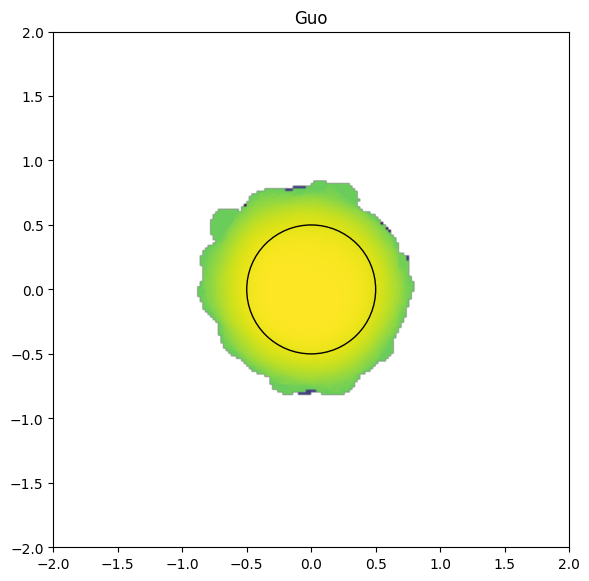

In [30]:
fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
plot_kde(ax, kde_guo, 2, title="Guo")

In [31]:
print(f"KL (Guo): {estimate_KL(kde_guo):.4f}")

KL (Guo): 0.1819
